# Model Comparison — PySpark vs TensorFlow, 7 Features vs All Features

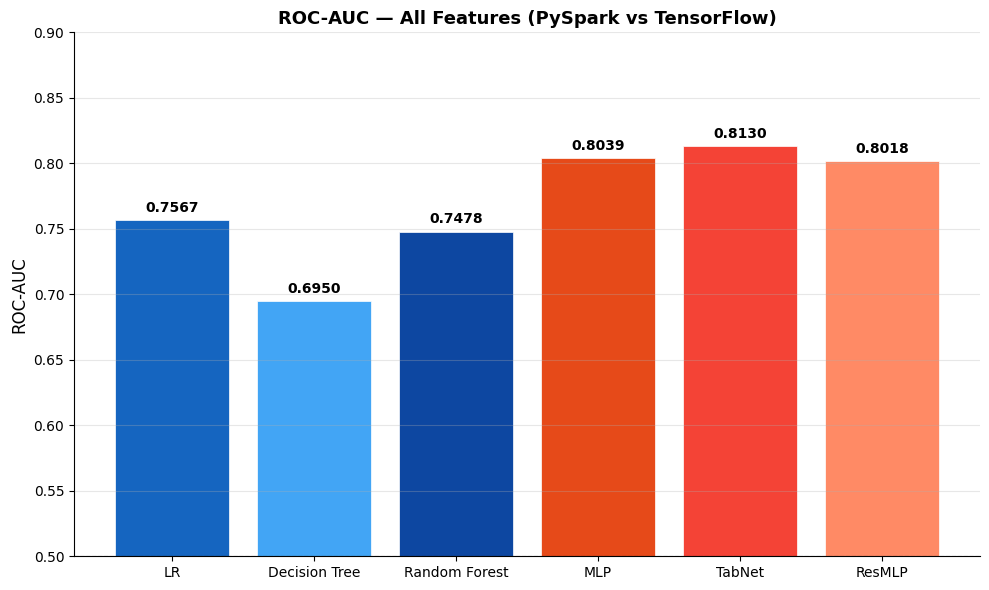

In [6]:
import matplotlib.pyplot as plt

models = ['LR', 'Decision Tree', 'Random Forest', 'MLP', 'TabNet', 'ResMLP']
roc_auc = [0.7567, 0.6950, 0.7478, 0.8039, 0.8130, 0.8018]
colors  = ['#1565C0', '#42A5F5', '#0D47A1', '#E64A19', '#F44336', '#FF8A65']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(models, roc_auc, color=colors, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, roc_auc):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.004,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('ROC-AUC', fontsize=12)
ax.set_title('ROC-AUC — All Features (PySpark vs TensorFlow)', fontsize=13, fontweight='bold')
ax.set_ylim(0.5, 0.90)
ax.axhline(0.5, color='black', linestyle='--', linewidth=0.8, alpha=0.4)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('output.png', dpi=150, bbox_inches='tight')
plt.show()

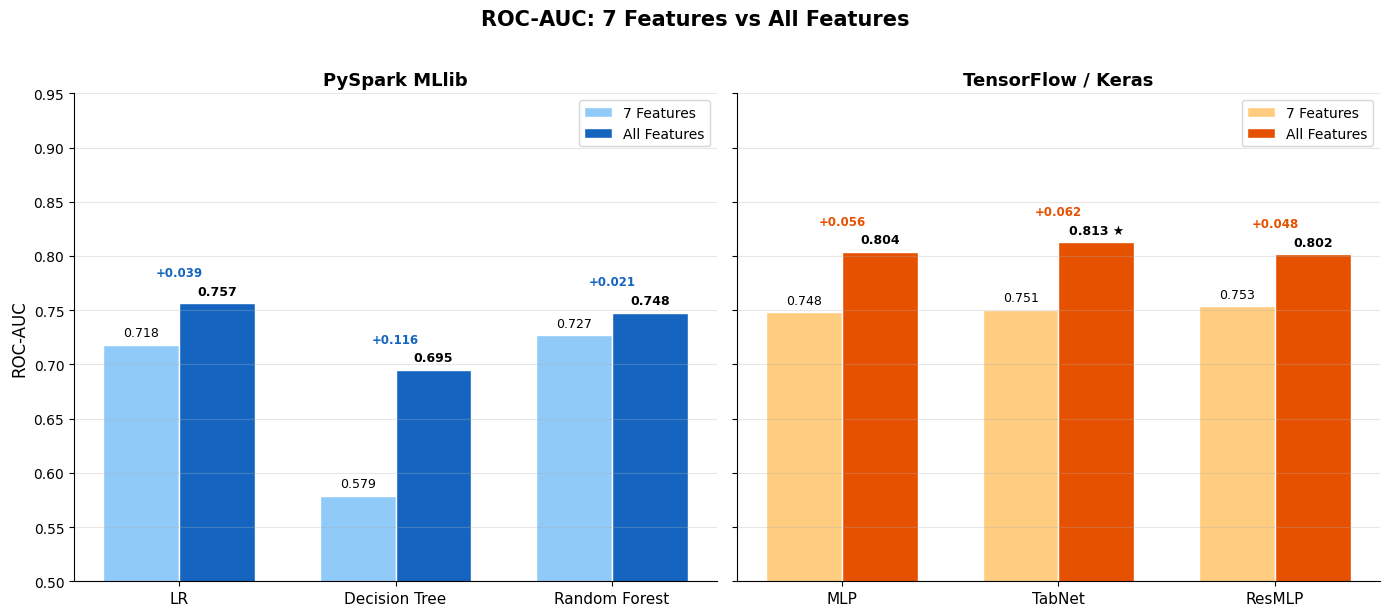

Saved → output.png


In [7]:
import numpy as np
import matplotlib.pyplot as plt

models_pyspark = ['LR', 'Decision Tree', 'Random Forest']
models_tf      = ['MLP', 'TabNet', 'ResMLP']

roc_pyspark_7   = [0.7182, 0.5790, 0.7267]
roc_pyspark_all = [0.7567, 0.6950, 0.7478]
roc_tf_7        = [0.7479, 0.7506, 0.7535]
roc_tf_all      = [0.8039, 0.8130, 0.8018]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
fig.suptitle('ROC-AUC: 7 Features vs All Features', fontsize=15, fontweight='bold', y=1.02)

width = 0.35
x = np.arange(3)

# --- PySpark ---
ax = axes[0]
b1 = ax.bar(x - width/2, roc_pyspark_7,   width, label='7 Features',  color='#90CAF9', edgecolor='white')
b2 = ax.bar(x + width/2, roc_pyspark_all, width, label='All Features', color='#1565C0', edgecolor='white')

for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

for i, (v7, va) in enumerate(zip(roc_pyspark_7, roc_pyspark_all)):
    ax.annotate(f'+{va-v7:.3f}', xy=(x[i], va + 0.025), ha='center',
                fontsize=8.5, color='#1565C0', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(models_pyspark, fontsize=11)
ax.set_title('PySpark MLlib', fontsize=13, fontweight='bold')
ax.set_ylabel('ROC-AUC', fontsize=12)
ax.set_ylim(0.5, 0.95)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

# --- TensorFlow ---
ax = axes[1]
b3 = ax.bar(x - width/2, roc_tf_7,   width, label='7 Features',  color='#FFCC80', edgecolor='white')
b4 = ax.bar(x + width/2, roc_tf_all, width, label='All Features', color='#E65100', edgecolor='white')

for bar in b3:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in b4:
    val = bar.get_height()
    star = ' ★' if val == max(roc_tf_all) else ''
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
            f'{val:.3f}{star}', ha='center', va='bottom', fontsize=9, fontweight='bold')

for i, (v7, va) in enumerate(zip(roc_tf_7, roc_tf_all)):
    ax.annotate(f'+{va-v7:.3f}', xy=(x[i], va + 0.025), ha='center',
                fontsize=8.5, color='#E65100', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(models_tf, fontsize=11)
ax.set_title('TensorFlow / Keras', fontsize=13, fontweight='bold')
ax.set_ylim(0.5, 0.95)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('output.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → output.png")